Environment: `velocity`

In [1]:
import scanpy
import anndata
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import scvelo
import seaborn
import pandas
import warnings
import cellrank
import gseapy
import decoupler
import IPython

In [2]:
# Read input file
working_directory = "RNA Sequencing Data/"

# adata = scanpy.read_h5ad(working_directory + "/velocity_sdevelo.h5ad")

# Or read saved anndata objects
working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_5"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)
combined_driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes_combined.csv",
    index_col=0
)

In [3]:
# Read ChIP-seq targets
base_name = "ChIP Sequencing Data/chipseq_targets"

hic2_target_scores = pandas.read_csv(f"{base_name}_hic2_scores.csv", index_col=0)
klf4_hic2_target_scores = pandas.read_csv(f"{base_name}_klf4_hic2_scores.csv", index_col=0)
klf4_control_target_scores = pandas.read_csv(f"{base_name}_klf4_control_scores.csv", index_col=0)

hic2_targets = numpy.loadtxt(f"{base_name}_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_hic2_targets = numpy.loadtxt(f"{base_name}_klf4_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_control_targets = numpy.loadtxt(f"{base_name}_klf4_control_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
shared_targets = numpy.intersect1d(hic2_targets, klf4_targets)

In [4]:
# Load bulk differential expression results

bulk_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_combined.csv", index_col=0)
bulk_metadata = pandas.read_csv("RNA Sequencing Data/bulk_sequencing_metadata.csv", index_col=0)
samples = bulk_metadata.index.to_list()
reprogramming_columns = bulk_de.columns[bulk_de.columns.str.contains("Reprogramming")]
reprogramming_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_reprogramming.csv", index_col=0)
mef_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_mef.csv", index_col=0)
mesc_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_mesc.csv", index_col=0)
ipsc_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_ipsc.csv", index_col=0)

In [5]:
# Variable genes and Cellrank drivers
variable_genes = adata.var_names.to_numpy()
variable_in_bulk = numpy.intersect1d(variable_genes, bulk_de.index.to_numpy())
stem_cell_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=True).head(100).index.to_numpy()
dead_end_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=False).head(100).index.to_numpy()
differentially_expressed_genes = reprogramming_de.loc[variable_in_bulk].query("padj < 0.05").index.to_numpy()

In [6]:
# Load list of transcription factors

tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()

# All target transcription factors
target_tfs = numpy.intersect1d(shared_targets, tf_array)

# Target transcription factors for which Hic2 changes expression significantly
de_target_tfs = numpy.intersect1d(target_tfs, differentially_expressed_genes)

de_dead_end_drivers = numpy.intersect1d(de_target_tfs, dead_end_drivers)
de_stem_cell_drivers = numpy.intersect1d(de_target_tfs, stem_cell_drivers)

In [7]:
genes_of_interest = de_dead_end_drivers.tolist() + de_stem_cell_drivers.tolist() + ["Klf4", "Myc", "Hic2", "Cdh1"]

In [8]:
# Show all possible libraries
names = gseapy.get_library_name(organism="Mouse")
print(names)

['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

Databases available in Decoupler: https://omnipathdb.org/info.html

In [ ]:
# Load databases

collectri_df = decoupler.op.collectri(organism="mouse")
progeny_df = decoupler.op.progeny(organism="mouse")
hallmark_df = decoupler.op.hallmark(organism="mouse")

# Differential expression analysis with Scanpy

Scanpy uses a Wilcoxon rank sum test.

In [12]:
# Assign each cell to the most likely macrostate

macrostates = adata.uns["coarse_fwd"].obs["coarse_init_dist"].index.to_list()
macrostate_assignment = [macrostates[numpy.argmax(macrostate_probabilities)] for macrostate_probabilities in adata.obsm["macrostates_fwd_memberships"]]
adata.obs["macrostate"] = macrostate_assignment
adata.uns["macrostate_colors"] = [
    adata.uns["macrostates_fwd_colors"][5],
    adata.uns["macrostates_fwd_colors"][2],
    adata.uns["macrostates_fwd_colors"][3],
    adata.uns["macrostates_fwd_colors"][4],
    adata.uns["macrostates_fwd_colors"][1],
    adata.uns["macrostates_fwd_colors"][0],
    adata.uns["macrostates_fwd_colors"][6]
]

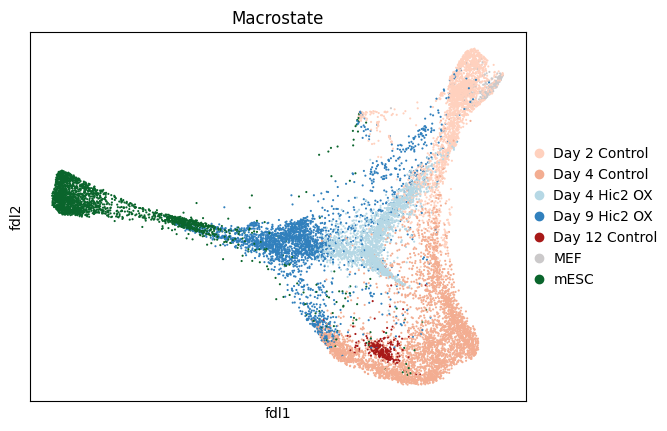

In [209]:
# Plot macrostates

scanpy.pl.embedding(adata, basis="fdl", color="macrostate", title="Macrostate")

# Comparison between macrostates

In [112]:
# Use the matrix layer with both spliced and unspliced

adata.layers["matrix"] = scanpy.pp.log1p(adata.layers["matrix"])

In [116]:
# perform differential expression using the standard wilcoxon rank-sum test

scanpy.tl.rank_genes_groups(
    adata,
    groupby="macrostate",
    method="wilcoxon",
    key_added="macrostate_rank_genes",
    layer="matrix",
    use_raw=False
)

# extract the results into a dataframe for a specific target macrostate
dead_end_rank_df = scanpy.get.rank_genes_groups_df(
    adata,
    key="macrostate_rank_genes",
    group="Day 12 Control"
)
dead_end_rank_df.index = dead_end_rank_df["names"]
dead_end_rank_df = dead_end_rank_df.drop(columns="names")

control_rank_df = scanpy.get.rank_genes_groups_df(
    adata,
    key="macrostate_rank_genes",
    group="Day 4 Control"
)
control_rank_df.index = control_rank_df["names"]
control_rank_df = control_rank_df.drop(columns="names")

mef_rank_df = scanpy.get.rank_genes_groups_df(
    adata,
    key="macrostate_rank_genes",
    group="MEF"
)
mef_rank_df.index = mef_rank_df["names"]
mef_rank_df = mef_rank_df.drop(columns="names")

early_rank_df = scanpy.get.rank_genes_groups_df(
    adata,
    key="macrostate_rank_genes",
    group="Day 2 Control"
)
early_rank_df.index = early_rank_df["names"]
early_rank_df = early_rank_df.drop(columns="names")

hic2_rank_df = scanpy.get.rank_genes_groups_df(
    adata,
    key="macrostate_rank_genes",
    group="Day 4 Hic2 OX"
)
hic2_rank_df.index = hic2_rank_df["names"]
hic2_rank_df = hic2_rank_df.drop(columns="names")

late_rank_df = scanpy.get.rank_genes_groups_df(
    adata,
    key="macrostate_rank_genes",
    group="Day 9 Hic2 OX"
)
late_rank_df.index = late_rank_df["names"]
late_rank_df = late_rank_df.drop(columns="names")

mesc_rank_df = scanpy.get.rank_genes_groups_df(
    adata,
    key="macrostate_rank_genes",
    group="mESC"
)
mesc_rank_df.index = mesc_rank_df["names"]
mesc_rank_df = mesc_rank_df.drop(columns="names")

## Dead end state

In [117]:
# Most upregulated genes

dead_end_rank_df.head(20)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Zfas1,21.173996,0.832372,1.658761e-99,8.244041e-97
Aqp3,20.489449,3.021472,2.674038e-93,7.594267e-91
Snhg12,20.269077,1.361212,2.411342e-91,5.992184e-89
Snhg1,20.070787,0.822983,1.328829e-89,2.935235e-87
2410006H16Rik,20.032635,0.582968,2.861119e-89,5.687905e-87
1110038B12Rik,18.979704,0.733373,2.510075e-80,2.376204e-78
Atf3,18.565245,3.366064,6.140769e-77,5.086604e-75
Ppp1r15a,18.307306,1.523872,7.236202e-75,5.327989e-73
Dkkl1,18.150793,2.165016,1.265624e-73,8.985928e-72


In [118]:
# Most upregulated transcription factors in dead end

dead_end_rank_df.loc[numpy.intersect1d(tf_array, adata.var_names)].sort_values("scores", ascending=False).head(30)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Atf3,18.565245,3.366064,6.140769e-77,5.086604e-75
Maff,13.679413,2.373999,1.347761e-42,2.527688e-41
Ddit3,11.394626,1.388661,4.447376e-30,4.805100e-29
Ovol1,11.081243,2.122284,1.547106e-28,1.530173e-27
Crebrf,9.362022,1.347894,7.822494e-21,5.218496e-20
Myc,9.019162,0.822836,1.895333e-19,1.148757e-18
Klf10,8.815069,0.903575,1.196115e-18,6.973244e-18
Zbtb7c,8.555893,1.166626,1.169595e-17,6.458766e-17
Zbtb10,8.534754,1.296065,1.404547e-17,7.692121e-17


Really exciting! The top three TFs are involved in stress response, suggesting that this macrostate corresponds to high activity of 

In [119]:
# Most upregulated transcription factors in dead end that are shared targets

dead_end_rank_df.loc[numpy.intersect1d(target_tfs, adata.var_names)].sort_values("scores", ascending=False).head(30)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Ddit3,11.394626,1.388661,4.447376e-30,4.805100e-29
Ovol1,11.081243,2.122284,1.547106e-28,1.530173e-27
Myc,9.019162,0.822836,1.895333e-19,1.148757e-18
Klf10,8.815069,0.903575,1.196115e-18,6.973244e-18
Zbtb7c,8.555893,1.166626,1.169595e-17,6.458766e-17
Arid3a,7.838533,0.910153,4.558390e-15,2.122267e-14
Phox2a,6.612563,1.367053,3.777234e-11,1.372786e-10
Barx2,6.251344,2.092648,4.069344e-10,1.359640e-09
Junb,5.678843,0.456869,1.356086e-08,4.072356e-08


In [120]:
# Most downregulated transcription factors in dead end

dead_end_rank_df.loc[numpy.intersect1d(tf_array, adata.var_names)].sort_values("scores", ascending=True).head(30)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Cenpa,-15.926634,-1.618726,4.140528e-57,1.553088e-55
Hmgb2,-15.657958,-0.997685,2.931616e-55,1.004837e-53
Terf1,-12.112407,-1.149634,9.079086e-34,1.107314e-32
Cdc5l,-11.929222,-0.719804,8.334891e-33,9.981786e-32
Jarid2,-11.119123,-1.377922,1.012631e-28,1.021883e-27
Tcf7l1,-11.116076,-1.867957,1.047792e-28,1.052025e-27
Id3,-10.884273,-2.314004,1.369875e-27,1.321996e-26
Prrx1,-9.897840,-3.038191,4.253618e-23,3.155295e-22
Nfib,-9.832184,-2.273209,8.182498e-23,5.980443e-22


In [121]:
dead_end_rank_df.loc[genes_of_interest].sort_values("scores", ascending=False)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Ovol1,11.081243,2.122284,1.547106e-28,1.530173e-27
Cdh1,10.455830,1.092228,1.377873e-25,1.180695e-24
Myc,9.019162,0.822836,1.895333e-19,1.148757e-18
Zbtb7c,8.555893,1.166626,1.169595e-17,6.458766e-17
Klf4,5.387359,0.596472,7.150038e-08,2.021945e-07
Tlx2,3.337677,0.509384,8.448178e-04,1.686243e-03
Hic2,-4.555451,-0.683143,5.227318e-06,1.268853e-05
Zfp42,-8.510460,-1.217609,1.732442e-17,9.358955e-17
Rest,-9.763539,-0.746783,1.614218e-22,1.158507e-21


In [122]:
# Cell types in the dead end

pre_res = gseapy.prerank(
    rnk=dead_end_rank_df[["scores"]], 
    gene_sets="PanglaoDB_Augmented_2021",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 15:41:26,963 [WARNING] Duplicated values found in preranked stats: 2.57% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Mammary Epithelial Cells,0.749732,2.791836,0.0,0.0,0.0,27/43,13.18%,S100a14;Krt17;Nectin4;Krt8;Mal2;Perp;Dsp;Lad1;...
1,prerank,Trichocytes,0.791244,2.749839,0.0,0.0,0.0,20/31,12.93%,S100a14;Krt17;Krt8;Perp;Dsp;Lad1;S100a16;Epha2...
2,prerank,Luminal Epithelial Cells,0.728396,2.673837,0.0,0.0,0.0,19/40,6.89%,Aqp3;Crb3;S100a14;Nectin4;Krt8;Mal2;Perp;Dsp;B...
3,prerank,Keratinocytes,0.716926,2.613163,0.0,0.0,0.0,17/41,10.66%,Aqp3;Lgals7;S100a14;Krt17;Nectin4;Perp;Lad1;Ov...
4,prerank,Gastric Chief Cells,0.853401,2.568755,0.0,0.0,0.0,11/19,6.89%,Crb3;S100a14;Mal2;Dsp;Lad1;Rab25;Spint1;Cdh1;S...
5,prerank,Cholangiocytes,0.739522,2.51233,0.0,0.0,0.0,14/28,6.89%,Crb3;S100a14;Krt8;Mal2;Lad1;Rab25;Ovol1;Cdh1;C...
6,prerank,Principal Cells,0.691047,2.402339,0.0,0.0,0.0,13/29,6.89%,Aqp3;S100a14;Mal2;Dsp;Lad1;Rab25;Ovol1;Cdh1;Cl...
7,prerank,Goblet Cells,0.758481,2.34094,0.0,0.0,0.0,9/20,6.64%,Aqp3;S100a14;Krt8;Lad1;Rab25;Cldn7;Misp;Pkp3;Gpx2
8,prerank,Sebocytes,0.668747,2.288389,0.0,0.0,0.0,18/31,12.93%,Aqp3;Crb3;Cxcl16;S100a14;Lad1;Rab25;Spint1;Ovo...
9,prerank,Salivary Mucous Cells,0.670224,2.268143,0.0,0.0,0.0,13/30,10.66%,Lgals7;S100a14;Krt17;Nectin4;Klk11;Nupr1;Pkp1;...


In [124]:
# MSig Hallmarks in dead end

pre_res = gseapy.prerank(
    rnk=dead_end_rank_df[["scores"]], 
    gene_sets="MSigDB_Hallmark_2020",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 15:42:21,829 [WARNING] Duplicated values found in preranked stats: 2.57% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,p53 Pathway,0.524808,2.064693,0.0,0.002238,0.001,22/60,8.10%,Atf3;Ppp1r15a;Krt17;Tob1;Ndrg1;Cdkn1a;Perp;Btg...
4,prerank,TNF-alpha Signaling via NF-kB,0.417686,1.776289,0.0,0.054824,0.049,26/83,12.22%,Atf3;Ppp1r15a;Gch1;Cdkn1a;Maff;Sqstm1;Btg1;Btg...
7,prerank,Estrogen Response Early,0.399261,1.514149,0.008929,0.214822,0.251,14/51,8.20%,Aqp3;Tob1;Krt8;Lad1;Ablim1;Cldn7;Myc;Klf10;Klk...
10,prerank,UV Response Up,0.392195,1.407664,0.025641,0.281394,0.384,6/38,2.11%,Aqp3;Atf3;Gch1;Sqstm1;Btg1;Btg2
11,prerank,KRAS Signaling Dn,0.414819,1.407443,0.066667,0.225563,0.385,4/30,3.12%,Lgals7;Btg2;Alox12b;Pkp1
15,prerank,mTORC1 Signaling,0.364492,1.285245,0.076923,0.349831,0.59,8/36,3.22%,Ppp1r15a;Ifrd1;Cdkn1a;Sqstm1;Btg2;Ddit3;Nupr1;...
18,prerank,Hypoxia,0.302738,1.230864,0.026667,0.370503,0.671,22/77,10.92%,Atf3;Ppp1r15a;Ndrg1;Cdkn1a;Maff;Btg1;Ddit3;Dus...
20,prerank,Unfolded Protein Response,0.470652,1.207115,0.193277,0.359155,0.706,5/10,12.32%,Atf3;Ddit4;Dnajb9;Vegfa;Chac1
26,prerank,Androgen Response,0.33476,1.072408,0.352041,0.59971,0.885,6/25,5.58%,Krt8;Ndrg1;Sat1;Homer2;Zbtb10;Dnajb9
28,prerank,Estrogen Response Late,0.266356,1.023476,0.358696,0.667961,0.937,14/55,10.76%,Tob1;Perp;Klk11;Cdh1;Homer2;St14;Lsr;Klk10;Pkp...


In [125]:
# GO biological process in dead end

pre_res = gseapy.prerank(
    rnk=dead_end_rank_df[["scores"]], 
    gene_sets="GO_Biological_Process_2025",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)[["Term", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]]

2026-03-09 15:42:31,805 [WARNING] Duplicated values found in preranked stats: 2.57% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,NES,NOM p-val,FWER p-val,FDR q-val
0,Positive Regulation of Intrinsic Apoptotic Sig...,1.786189,0.017391,0.892,1.0
5,Positive Regulation of Neuron Apoptotic Proces...,1.696828,0.033333,0.988,1.0
9,Regulation of Glycolytic Process (GO:0006110),1.637455,0.034884,0.999,1.0
11,Response to Endoplasmic Reticulum Stress (GO:0...,1.631744,0.019417,0.999,1.0
18,Reg of Endoplasmic Reticulum Stress-Induced In...,1.599776,0.043919,1.0,1.0
19,Regulation of Intrinsic Apoptotic Signaling Pa...,1.587339,0.041353,1.0,1.0
20,Positive Regulation of Response to Endoplasmic...,1.583781,0.054745,1.0,1.0
25,Negative Regulation of Transport (GO:0051051),1.5549,0.058824,1.0,1.0
28,Positive Regulation of Sprouting Angiogenesis ...,1.548634,0.029167,1.0,1.0
30,Positive Regulation of Apoptotic Signaling Pat...,1.537278,0.066372,1.0,1.0


In [129]:
# TFs whose targets are upregulated in dead end, perturbation followed by expression
pre_res = gseapy.prerank(
    rnk=dead_end_rank_df[["scores"]], 
    gene_sets="TF_Perturbations_Followed_by_Expression",
    threads=32,
    min_size=5,
    max_size=1000
)
print("Top")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=False).head(20))
print("Bottom")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=True).head(20))

2026-03-09 15:43:00,012 [WARNING] Duplicated values found in preranked stats: 2.57% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Top


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
115,prerank,NR1I2 KO MOUSE GSE23780 CREEDSID GENE 2165 DOWN,0.68164,1.931291,0.0,0.07235,0.081,5/17,12.17%,Cdkn1a;Alox12b;Scara5;Pdlim4;Map4k1
147,prerank,MYC OE MOUSE GSE55272 CREEDSID GENE 1822 DOWN,0.517872,1.899454,0.0,0.045117,0.099,15/49,11.02%,Lgals7;Krt17;Ly6g6c;Mal2;Perp;Dsp;Ovol1;Cdh1;M...
196,prerank,GLI1 INHIBITION HUMAN GSE36855 CREEDSID GENE 6...,0.541669,1.855726,0.0,0.046066,0.147,9/33,3.87%,Snhg12;Snhg1;Atf3;Ppp1r15a;Gas5;Nrip3;Ddit3;Cr...
477,prerank,MBD3 KD MOUSE GSE31008 CREEDSID GENE 1325 UP,0.402906,1.653764,0.0,0.194086,0.558,23/78,10.46%,Lgals7;Crb3;Cxcl16;S100a14;Mal2;Perp;Lad1;Cldn...
507,prerank,EGR4 KD HUMAN GSE40558 CREEDSID GENE 3030 UP,0.501284,1.633246,0.005917,0.182095,0.619,8/25,15.29%,Cdkn1a;Rab25;Stmn4;Gdf15;Slc7a3;Cpm;Cldn6;Cd109
510,prerank,PLAGL2 DEFICIENCY MOUSE GSE9123 CREEDSID GENE ...,0.414054,1.632581,0.0,0.152423,0.619,18/51,10.11%,Ndrg1;Dpp7;Cstb;Sat1;Cldn7;Renbp;Smpdl3a;Dgat2...
608,prerank,HMGA2 OE MOUSE GSE24071 CREEDSID GENE 2563 DOWN,0.510541,1.569759,0.009756,0.216354,0.784,3/19,8.00%,Btg2;Tmbim1;Plbd1
624,prerank,XBP1 KO MOUSE GSE52857 CREEDSID GENE 2765 UP,0.443279,1.562915,0.007519,0.199065,0.804,13/33,12.32%,Atf3;Ndrg1;Cdkn1a;Ddit3;Dusp1;Tnfrsf13c;Klf4;P...
629,prerank,ARID3A KD MOUSE GSE56853 CREEDSID GENE 1337 UP,0.371947,1.559961,0.0,0.181372,0.81,40/142,10.31%,Aqp3;Crb3;Gch1;Nectin4;Krt8;Ndrg1;Mal2;Cdkn1a;...
646,prerank,STAT3 ACTVATION MOUSE GSE21060 CREEDSID GENE 3...,0.508814,1.548291,0.038835,0.17803,0.828,5/17,7.70%,Tob1;Dusp1;Ddit4;Plk2;Dqx1


Bottom


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,DNMT1 KO MOUSE GSE31626 CREEDSID GENE 1237 DOWN,-0.773655,-2.281042,0.0,0.0,0.0,40/56,16.45%,Tmsb10;Actb;Tmsb4x;Pfn1;Sh3bgrl3;Lgals1;Vim;Db...
1,prerank,TAL1 KD JURKAT HUMAN GSE72299 RNASEQ DOWN,-0.868858,-2.279351,0.0,0.0,0.0,23/28,9.46%,Actb;Ptma;Hnrnpa3;Vim;Ccnb2;Lmnb1;Rrm2;Cdk1;Bi...
2,prerank,RC3H1 SIRNA HEK293 HUMAN GSE68611 RNASEQ UP,-0.804933,-2.25465,0.0,0.0,0.0,33/47,12.37%,Tmsb10;Actb;Marcksl1;Pfn1;Cfl1;Tpm1;Hnrnpa3;Vi...
3,prerank,NFKB1 INACTIVATION HUMAN GSE20667 CREEDSID GEN...,-0.809855,-2.237388,0.0,0.0,0.0,26/41,9.41%,Actb;Tmsb4x;Gpx4;Ptma;Pfn1;Sh3bgrl3;Cfl1;Hnrnp...
4,prerank,MEIS2 KD KASUMI1 HUMAN GSE81328 RNASEQ UP,-0.771635,-2.233701,0.0,0.0,0.0,38/50,18.01%,Actb;Tmsb4x;Ptma;Hnrnpa3;G3bp2;Msn;Lmnb1;Hmgn2...
5,prerank,MYCN SHRNA SKNBE2 HUMAN GSE84389 RNASEQ DOWN,-0.745784,-2.224241,0.0,0.0,0.0,44/67,14.49%,Actb;Marcksl1;Ptma;Pfn1;Cfl1;Lgals1;Ccnb2;Msn;...
6,prerank,YEATS2 SHRNA H1299 HUMAN GSE90781 RNASEQ DOWN,-0.756575,-2.197352,0.0,0.0,0.0,36/57,9.41%,Tmsb10;Actb;Ptma;Pfn1;Cfl1;Lgals1;Hnrnpa3;Vim;...
7,prerank,NFKB1 INACTIVATION HUMAN GSE20667 CREEDSID GEN...,-0.78497,-2.195359,0.0,0.0,0.0,25/40,9.41%,Tmsb10;Tmsb4x;Marcksl1;Cfl1;Dbi;Rrm2;Cenpa;Cdk...
8,prerank,BNC2 SIRNA BT549 HUMAN GSE79586 RNASEQ UP,-0.732585,-2.18043,0.0,0.0,0.0,45/72,14.49%,Tmsb10;Tmsb4x;Gpx4;Ptma;Pfn1;Hnrnpa3;G3bp2;Vim...
9,prerank,OVOL2 OE PC3 HUMAN GSE48230 RNASEQ DOWN,-0.743415,-2.179632,0.0,0.0,0.0,37/57,14.03%,Actb;Tmsb4x;Ptma;Pfn1;Sh3bgrl3;Cfl1;Vim;Msn;Fs...


In [132]:
# TFs whose targets are upregulated in dead end, Chea
pre_res = gseapy.prerank(
    rnk=dead_end_rank_df[["scores"]], 
    gene_sets="ChEA_2022",
    threads=32,
    min_size=5,
    max_size=1000
)
print("Top")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=False).head(30))
print("Bottom")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=True).head(20))

2026-03-09 15:43:44,408 [WARNING] Duplicated values found in preranked stats: 2.57% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Top


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
6,prerank,TP63 17297297 ChIP-ChIP HaCaT Human,0.571494,1.763399,0.005128,0.177783,0.153,11/20,13.48%,Cdkn1a;Perp;Ddit4;Mdm2;Notch1;Itgb4;Gpx2;Krt14...
74,prerank,NOTCH1 21737748 ChIP-Seq TLL Human,0.475482,1.413686,0.082609,0.774778,0.728,5/18,11.97%,Ppp1r15a;Myc;Phlda3;Dusp5;Hes1
75,prerank,RELB 30642670 ChIP-Seq CTB1 Human Placenta Inf...,0.407493,1.410446,0.029851,0.524233,0.732,10/33,10.92%,Ppp1r15a;Tob1;Cdkn1a;Dusp1;Ddit4;Bhlhe40;Nfkbi...
77,prerank,FOXA1 33576154 ChIP-Seq Human HilarLN Prostate...,0.338629,1.406811,0.016129,0.402117,0.734,18/84,9.21%,Atf3;Ifrd1;Krt8;Ndrg1;Mal2;Maff;Btg1;Dusp1;Nup...
164,prerank,HCFC1 20581084 ChIP-Seq MESCs Mouse,0.615465,1.277874,0.205882,0.65054,0.935,2/6,1.26%,Ifrd1;Tmem43
223,prerank,PKCTHETA 26484144 Chip-Seq BREAST Human,0.326669,1.217856,0.104167,0.762856,0.975,10/52,5.89%,Bbc3;Tob1;Tmem43;Rassf1;Btg2;Ddit4;Plk2;Myc;Kl...
245,prerank,P63 26484246 Chip-Seq KERATINOCYTES Human,0.243336,1.20119,0.0,0.712787,0.983,54/233,12.47%,Lgals7;Bbc3;S100a14;Krt8;Cdkn1a;Perp;Dsp;Klk11...
293,prerank,NFE2L2 22581777 ChIP-Seq LYMPHOBLASTOID Human,0.298633,1.169715,0.105263,0.745323,0.995,15/65,8.25%,Cdkn1a;Aldh3a1;Zfand5;Ablim1;Dlgap1;Dusp1;Trpv...
294,prerank,STAT5A 28732065 ChIP-Seq J2E Mouse Blood,0.473124,1.16722,0.230159,0.67338,0.996,2/9,3.62%,Maff;Crebrf
319,prerank,ERG 21242973 ChIP-ChIP JURKAT Human,0.307334,1.145132,0.144068,0.692304,0.998,6/44,7.34%,Ndrg1;Rassf1;Cdh1;Cldn7;Trim47;Uap1l1


Bottom


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,FOXM1 23109430 ChIP-Seq U2OS Human,-0.761878,-2.122338,0.0,0.0,0.0,29/41,12.98%,Lgals1;Ccnb2;Lmnb1;Rrm2;Cenpa;Cdk1;Hmgb2;Pttg1...
1,prerank,E2F4 17652178 ChIP-ChIP JURKAT Human,-0.710255,-2.054688,0.0,0.0,0.0,31/52,11.82%,Nedd4;Ptma;Ccnb2;Lmnb1;Rrm2;Cenpa;Hmgb2;Hells;...
2,prerank,FOXM1 25889361 ChIP-Seq OE33 AND U2OS Human,-0.633264,-1.924193,0.0,0.0,0.0,47/78,21.48%,Lgals1;Ccnb2;Lmnb1;Rrm2;Cenpa;Cdk1;Hmgb2;Birc5...
3,prerank,GABP 19822575 ChIP-Seq HepG2 Human,-0.60254,-1.818949,0.0,0.000997,0.004,37/79,18.51%,Actb;Marcksl1;Ptma;Cfl1;Tpm1;G3bp2;Tln1;Ppa1;P...
4,prerank,EKLF 21900194 ChIP-Seq ERYTHROCYTE Mouse,-0.600781,-1.813906,0.0,0.001396,0.007,43/88,17.61%,Ptma;Pfn1;Ly6e;Sh3bgrl3;Cfl1;Lgals1;Vim;Dbi;Ms...
5,prerank,ELK1 19687146 ChIP-ChIP HELA Human,-0.612169,-1.78345,0.0,0.002992,0.018,30/62,20.72%,Nedd4;Tpm1;Dbi;Ccnb2;Csrp2;Prdx5;Serpinh1;Myl6...
7,prerank,FOXM1 26456572 ChIP-Seq MCF-7 Human BreastCancer,-0.589616,-1.755797,0.0,0.004417,0.028,34/65,17.96%,Ccnb2;Lmnb1;Rrm2;Cenpa;Cdk1;Hmgb2;Pttg1;Top2a;...
8,prerank,E2F4 21247883 ChIP-Seq LYMPHOBLASTOID Human,-0.541117,-1.724804,0.0,0.005985,0.045,75/176,18.86%,Marcksl1;Nedd4;Pfn1;Sh3bgrl3;Cfl1;Tpm1;Vim;Ccn...
9,prerank,RUNX2 24655370 ChIP-Seq MC3T3E1 Mouse Bone,-0.510675,-1.683412,0.0,0.013742,0.109,188/360,29.48%,Tmsb10;Actb;Pfn1;Ifitm3;Sh3bgrl3;Sparc;Tpm1;Hn...
10,prerank,MYC 28411283 ChIP-Seq MDA231-LM2-4175 Human Br...,-0.525166,-1.674533,0.0,0.014961,0.129,71/143,21.48%,Tmsb10;Actb;Gpx4;Ptma;Pfn1;Cfl1;G3bp2;Vim;Dbi;...


In [134]:
# TFs whose targets are upregulated in dead end, ENCODE
pre_res = gseapy.prerank(
    rnk=dead_end_rank_df[["scores"]], 
    gene_sets="ENCODE_TF_ChIP-seq_2015",
    threads=32,
    min_size=5,
    max_size=1000
)
print("Top")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=False).head(30))
print("Bottom")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=True).head(20))

2026-03-09 15:43:59,897 [WARNING] Duplicated values found in preranked stats: 2.57% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Top


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
25,prerank,FOSL2 HepG2 hg19,0.453462,1.664859,0.0,0.165855,0.178,16/39,13.08%,Ppp1r15a;Ifrd1;Maff;Fam83g;Ddit3;Dusp1;Klf10;E...
26,prerank,NR2F2 MCF-7 hg19,0.444982,1.664204,0.0,0.083326,0.178,16/44,9.56%,Ifrd1;S100a14;Gch1;Gas5;Perp;Ddit3;Ovol1;Cstb;...
35,prerank,ZEB1 HepG2 hg19,0.517091,1.63379,0.011299,0.065917,0.212,7/22,6.64%,Crb3;Mal2;Spint1;Nupr1;Cdh1;Lsr;Gpx2
61,prerank,MAX myocyte mm9,0.396316,1.557472,0.0,0.089306,0.332,26/69,10.87%,Snhg1;2410006H16Rik;1110038B12Rik;Ndrg1;Tmem43...
101,prerank,NFE2 K562 hg19,0.544184,1.488327,0.029851,0.119447,0.475,5/14,5.84%,Ppp1r15a;Ifrd1;Ankrd12;Dnajb9;Hexa
108,prerank,ATF3 K562 hg19,0.371916,1.477156,0.0,0.107779,0.495,18/62,6.89%,Snhg12;Snhg1;Krt8;Tmem43;Gas5;Perp;Fam83g;Dpp7...
173,prerank,JUND MCF-7 hg19,0.424141,1.407974,0.046243,0.146831,0.636,12/27,13.23%,Ifrd1;Krt8;Fam83g;Spint1;Lsr;Hist1h2bc;Junb;Fo...
175,prerank,YY1 GM12891 hg19,0.379396,1.405127,0.02381,0.131169,0.643,15/41,8.85%,Snhg12;Snhg1;Ppp1r15a;Gas5;Btg1;Zfand5;Tmbim1;...
211,prerank,PML MCF-7 hg19,0.363738,1.369097,0.018868,0.148401,0.709,19/54,9.21%,Snhg12;Snhg1;Ppp1r15a;Btg2;Zfand5;Dusp1;Cstb;S...
219,prerank,NR3C1 ECC-1 hg19,0.375247,1.364026,0.049587,0.139302,0.72,12/39,12.93%,Ifrd1;Hmha1;Cdkn1a;Dusp1;Ddit4;Klf10;Epha2;Rra...


Bottom


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,E2F4 MEL cell line mm9,-0.757089,-2.07096,0.0,0.0,0.0,27/36,13.18%,Ptma;2810417H13Rik;H2afv;Lmnb1;Ccne1;Rrm2;Cdk1...
1,prerank,FOXM1 ECC-1 hg19,-0.671651,-2.05242,0.0,0.0,0.0,49/88,17.81%,Lgals1;H2afv;Ccnb2;Lmnb1;Rrm2;Cenpa;Cdk1;Hmgb2...
2,prerank,E2F4 HeLa-S3 hg19,-0.634458,-1.920005,0.0,0.001012,0.003,46/77,14.54%,H2afv;Lmnb1;Hmgn2;Ccne1;Rrm2;Cenpa;Cdk1;Hmgb2;...
3,prerank,E2F4 CH12.LX mm9,-0.60397,-1.869022,0.0,0.001012,0.004,64/99,21.98%,Ptma;Sh3bgrl3;Hnrnpa3;G3bp2;2810417H13Rik;H2af...
4,prerank,FOXM1 MCF-7 hg19,-0.708862,-1.865571,0.0,0.00081,0.004,18/29,12.42%,Ccnb2;Lmnb1;Cenpa;Cdk1;Hmgb2;Pttg1;Mki67;Cenpf...
5,prerank,IRF3 HeLa-S3 hg19,-0.598341,-1.843407,0.0,0.001349,0.007,47/103,13.58%,Actb;Gpx4;Ptma;H2afv;Ccnb2;Lmnb1;Rrm2;Cenpa;Cd...
6,prerank,NFYA GM12878 hg19,-0.595401,-1.837853,0.0,0.001156,0.007,59/111,22.18%,Actb;Gpx4;Ptma;Lgals1;Hnrnpa3;G3bp2;H2afv;Ccnb...
7,prerank,SP2 H1-hESC hg19,-0.632565,-1.830783,0.0,0.001012,0.007,28/53,19.11%,Ptma;Cfl1;H2afv;Tln1;Cenpa;Myh10;Top2a;Actn1;R...
8,prerank,POLR2A erythroblast hg19,-0.614991,-1.819368,0.0,0.001124,0.009,42/70,28.67%,Marcksl1;Gpx4;Cfl1;Timp1;Ppa1;Cdk1;Top2a;Rrbp1...
9,prerank,SP2 HepG2 hg19,-0.625291,-1.815693,0.0,0.001012,0.009,26/53,12.22%,Ptma;Cfl1;H2afv;Tln1;Cenpa;Hmgb2;Myh10;Top2a;A...


In [136]:
# Motif enrichment analysis, TRANSFAC and JASPAR

# Motifs upregulated in dead end
pre_res = gseapy.prerank(
    rnk=dead_end_rank_df[["scores"]], 
    gene_sets="TRANSFAC_and_JASPAR_PWMs",
    threads=32,
    min_size=5,
    max_size=1000
)
print("Top")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=False).head(30))
print("Bottom")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=True).head(20))

2026-03-09 15:44:14,372 [WARNING] Duplicated values found in preranked stats: 2.57% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Top


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
3,prerank,MIR210 (human),0.557927,1.473695,0.053333,0.729659,0.562,3/12,2.06%,S100a14;Krt17;Aldh3a1
12,prerank,TCF3 (human),0.316651,1.386242,0.0,0.378023,0.711,32/136,10.61%,Aqp3;Crb3;Bbc3;Krt17;Gch1;Krt8;Ly6g6c;Mal2;Cdk...
13,prerank,SNAI1 (human),0.316651,1.386242,0.0,0.378023,0.711,32/136,10.61%,Aqp3;Crb3;Bbc3;Krt17;Gch1;Krt8;Ly6g6c;Mal2;Cdk...
14,prerank,SNAI2 (human),0.313126,1.385986,0.0,0.283947,0.712,32/137,10.61%,Aqp3;Crb3;Bbc3;Krt17;Gch1;Krt8;Ly6g6c;Mal2;Cdk...
53,prerank,MYOD1 (human),0.486373,1.211683,0.2,0.512138,0.938,5/10,13.08%,Dlgap1;Renbp;Kiss1r;Fbxo32;Epcam
76,prerank,NCOA1 (human),0.512222,1.153009,0.270161,0.557282,0.973,2/7,8.80%,S100a14;Akap12
99,prerank,CEBPB (human),0.248053,1.109254,0.055556,0.594691,0.993,33/160,11.57%,Ifrd1;S100a14;Krt8;Ndrg1;Mal2;Sqstm1;Rassf1;Al...
101,prerank,MIB2 (human),0.241546,1.103171,0.166667,0.536273,0.993,35/164,9.96%,Lgals7;Bbc3;Cxcl16;Krt17;Perp;Sqstm1;Rassf1;Fa...
112,prerank,TFAP2C (human),0.247784,1.077747,0.090909,0.53797,0.997,27/165,8.85%,Aqp3;Cxcl16;Sqstm1;Ahnak2;Rassf1;Aldh3a1;Nrip3...
145,prerank,SMAD4 (human),0.222038,1.020427,0.4,0.639226,0.999,21/182,5.94%,Bbc3;S100a14;Ndrg1;Cdkn1a;Klk11;Ahnak2;Rassf1;...


Bottom


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HNF1B (human),-0.777417,-1.698396,0.002608,0.058576,0.056,5/12,5.73%,Sparc;Aes;Cald1;Gpx1;Spp1
1,prerank,Nkx2-5 (mouse),-0.571124,-1.582973,0.002304,0.185827,0.299,22/41,31.39%,Ly6e;Fn1;Ctgf;Pigp;Hsp90aa1;Ash2l;Fbxo15;Maged...
2,prerank,NRF1 (human),-0.507375,-1.5181,0.005342,0.314761,0.598,23/74,17.00%,Pfn1;G3bp2;Ppa1;Cdk1;Lrpap1;Maged1;Nt5dc2;Hmmr...
4,prerank,NFYA (mouse),-0.467171,-1.44772,0.001026,0.551925,0.883,68/119,36.12%,Gpx4;Ccnb2;Msn;Hmgb2;Pttg1;Basp1;Top2a;Mki67;H...
5,prerank,SP4 (human),-0.66134,-1.441568,0.031332,0.473454,0.9,5/11,23.44%,Ccne1;Dpysl3;Ccnd1;Gadd45b;Ptk7
6,prerank,FOXI1 (human),-0.624449,-1.441507,0.042362,0.394882,0.9,10/16,23.29%,Myh10;Nt5dc2;Ddah1;Terf1;Fam101b;Pigp;Sin3b;Ph...
7,prerank,EIF4EBP1 (human),-0.632984,-1.434177,0.042691,0.368912,0.916,8/14,21.23%,G3bp2;Rif1;Chd3;Brca1;Tdgf1;Zfhx4;Pla2g16;Plekhh2
8,prerank,SP3 (mouse),-0.442248,-1.409028,0.001017,0.440202,0.963,64/162,30.28%,Ptma;Vim;Hmgn2;Serpinh1;Basp1;Ckap4;Nid1;Anxa3...
9,prerank,SRF (mouse),-0.457036,-1.406602,0.008333,0.4024,0.966,36/100,31.64%,Cenpa;Cdk1;Psme1;Hat1;Maged1;Nusap1;Col5a2;Fam...
10,prerank,SOX10 (human),-0.59136,-1.391665,0.052963,0.428916,0.978,8/16,30.53%,Tln1;Cenpm;Enah;Id3;Col11a1;Tdrd12;Bdnf;Upp1


In [138]:
# TF activity in dead end CollecTRI

data = dead_end_rank_df[["scores"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=collectri_df)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["scores"], "Adjusted p-value": tf_padj.transpose()["scores"]}, index=tf_acts.columns)
activities_df.sort_values("Activity", ascending=False).head(30)

,Activity,Adjusted p-value
Trp73,3.680557,0.043604
Atf4,3.580520,0.043604
Irf1,3.342448,0.062715
Arnt,3.320804,0.062715
Ppara,3.243289,0.062715
Klf4,3.164767,0.062715
Trp53,3.149364,0.062715
Klf6,3.107594,0.062715
Atf6,2.987213,0.081754
Spdef,2.725038,0.175117


In [139]:
# Most downregulated in dead end

activities_df.sort_values("Activity", ascending=True).head(25)

,Activity,Adjusted p-value
Jdp2,-3.730600,0.043604
E2f2,-3.559709,0.043604
E2f4,-3.238593,0.062715
E2f1,-3.198728,0.062715
Srsf2,-3.169307,0.062715
E2f3,-3.125861,0.062715
Smad3,-3.041133,0.073064
Zfp42,-2.624138,0.203973
Myb,-2.575516,0.203973
Gli2,-2.552715,0.205841


In [140]:
# Progeny pathways in dead end

data = dead_end_rank_df[["scores"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=progeny_df)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["scores"], "Adjusted p-value": tf_padj.transpose()["scores"]}, index=tf_acts.columns)

IPython.display.display(activities_df.sort_values("Activity", ascending=False))

,Activity,Adjusted p-value
p53,11.345716,8.312343e-28
Hypoxia,3.607028,1.481090e-03
NFkB,3.231267,4.384068e-03
Trail,2.704384,1.610576e-02
TNFa,2.408869,3.218512e-02
VEGF,2.277677,3.999048e-02
Androgen,1.253117,2.676682e-01
EGFR,0.965808,3.899676e-01
MAPK,0.176331,8.956834e-01
WNT,0.131133,8.956834e-01


In [141]:
# Hallmark pathways in dead end

data = dead_end_rank_df[["scores"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=hallmark_df)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["scores"], "Adjusted p-value": tf_padj.transpose()["scores"]}, index=tf_acts.columns)

print("Top")
IPython.display.display(activities_df.sort_values("Activity", ascending=False).head(20))
print("Bottom")
IPython.display.display(activities_df.sort_values("Activity", ascending=True).head(20))

Top


,Activity,Adjusted p-value
P53_PATHWAY,5.792188,7.897665e-08
TNFA_SIGNALING_VIA_NFKB,4.805019,1.358398e-05
ESTROGEN_RESPONSE_EARLY,3.222751,7.902650e-03
UV_RESPONSE_UP,2.518381,4.845938e-02
HYPOXIA,2.457575,5.304353e-02
KRAS_SIGNALING_DN,2.398322,5.796751e-02
UNFOLDED_PROTEIN_RESPONSE,2.085426,1.137965e-01
MTORC1_SIGNALING,1.507494,3.228762e-01
ESTROGEN_RESPONSE_LATE,1.464106,3.228762e-01
WNT_BETA_CATENIN_SIGNALING,1.365374,3.247010e-01


Bottom


,Activity,Adjusted p-value
G2M_CHECKPOINT,-8.139824,3.385304e-14
E2F_TARGETS,-7.279548,8.624094e-12
EPITHELIAL_MESENCHYMAL_TRANSITION,-7.266410,8.624094e-12
MITOTIC_SPINDLE,-6.381660,2.663371e-09
INTERFERON_ALPHA_RESPONSE,-3.497881,3.355024e-03
OXIDATIVE_PHOSPHORYLATION,-3.136786,9.436006e-03
UV_RESPONSE_DN,-2.963261,1.509286e-02
ANGIOGENESIS,-2.781164,2.435555e-02
GLYCOLYSIS,-2.334403,6.426797e-02
APICAL_JUNCTION,-2.005795,1.297448e-01


## Day 4 control

In [142]:
# Most upregulated transcription factors in day 4 control

control_rank_df.loc[numpy.intersect1d(tf_array, adata.var_names)].sort_values("scores", ascending=False).head(30)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Tlx2,56.839550,3.899939,0.000000e+00,0.000000e+00
Dmrtc2,47.498425,3.469146,0.000000e+00,0.000000e+00
Hmgb3,45.477238,1.373836,0.000000e+00,0.000000e+00
Zbtb7c,44.280960,2.206178,0.000000e+00,0.000000e+00
Myc,40.487976,1.282774,0.000000e+00,0.000000e+00
Zbtb32,36.276093,1.897805,3.854943e-288,6.664022e-287
Ovol1,36.173790,3.298202,1.572881e-286,2.649905e-285
Hoxa9,29.866173,1.671045,5.413455e-196,5.880846e-195
Phox2a,29.071886,2.182351,8.140319e-186,8.132138e-185


In [143]:
# Cell types in control

pre_res = gseapy.prerank(
    rnk=control_rank_df[["scores"]], 
    gene_sets="PanglaoDB_Augmented_2021",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 15:46:03,637 [WARNING] Duplicated values found in preranked stats: 0.30% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
2,prerank,Mammary Epithelial Cells,0.72661,2.053276,0.0,0.000834,0.001,19/43,9.56%,S100a16;Krt8;Perp;Dsp;Lad1;Itgb4;Gjb3;Misp;Krt...
3,prerank,Epithelial Cells,0.672384,2.051293,0.0,0.000417,0.001,37/67,21.23%,Krt8;Lad1;Crb3;Krt13;Itgb4;Gjb3;Gpx2;Misp;Dgat...
4,prerank,Gastric Chief Cells,0.840844,2.04546,0.0,0.000278,0.001,13/19,11.27%,Tppp3;Dsp;Lad1;Crb3;Itgb4;St14;Cdh1;S100a14;Ma...
9,prerank,Keratinocytes,0.721582,2.00275,0.0,0.000208,0.001,24/41,18.81%,Lgals7;Perp;Anxa8;Lad1;Krt13;Itgb4;Gjb3;Pkp1;G...
10,prerank,Cholangiocytes,0.760612,1.99726,0.0,0.000167,0.001,16/28,11.27%,Krt8;Lad1;Crb3;Itgb4;Gpx2;Misp;St14;Cdh1;Ovol1...
12,prerank,Luminal Epithelial Cells,0.702983,1.976834,0.0,0.000139,0.001,26/40,18.61%,Krt8;Perp;Dsp;Lad1;Crb3;Cd9;Itgb4;Gjb3;Misp;St...
16,prerank,Hepatoblasts,0.784218,1.930764,0.0,0.000477,0.004,11/19,11.27%,Krt8;Dsp;Lad1;Cdh1;Krt14;S100a14;Mal2;Ahsg;Epc...
19,prerank,Trichocytes,0.710527,1.910597,0.0,0.000625,0.006,21/31,21.23%,S100a16;Krt8;Perp;Dsp;Lad1;Itgb4;Gjb3;Misp;Krt...
22,prerank,Ductal Cells,0.678405,1.880747,0.001397,0.001297,0.014,14/36,11.62%,S100a16;Krt8;Perp;Dsp;Lad1;Gpx2;Misp;Cdh1;S100...
23,prerank,Principal Cells,0.694984,1.87092,0.0,0.001501,0.018,19/29,18.46%,Dsp;Lad1;Itgb4;Zbtb7c;Cdh1;Ovol1;S100a14;Mal2;...


In [144]:
# MSig Hallmarks in day 4 control

pre_res = gseapy.prerank(
    rnk=control_rank_df[["scores"]], 
    gene_sets="MSigDB_Hallmark_2020",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 15:46:20,127 [WARNING] Duplicated values found in preranked stats: 0.30% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,E2F Targets,0.633854,1.658289,0.004225,0.144772,0.126,15/28,19.72%,Hmgb3;Myc;Cdkn1a;Cdc20;Tfrc;Birc5;Pttg1;Aurka;...
1,prerank,Estrogen Response Late,0.556576,1.648962,0.003922,0.082581,0.142,15/55,6.79%,Perp;Fabp5;Ccnd1;Homer2;Krt13;Cd9;Gjb3;Cd44;St...
3,prerank,G2-M Checkpoint,0.561179,1.562164,0.013532,0.154967,0.345,21/37,21.63%,Ccnd1;Hmgb3;Myc;Ncl;Cdc20;Birc5;Pttg1;Aurka;Br...
4,prerank,Estrogen Response Early,0.529416,1.561435,0.009409,0.11648,0.345,18/51,14.69%,Krt8;Ccnd1;Lad1;Tgm2;Krt13;Myc;Cd44;Klk10;Podx...
5,prerank,Myc Targets V1,0.886608,1.561207,0.011561,0.093796,0.347,4/5,8.80%,Myc;Cdc20;Ifrd1;Hsp90ab1
6,prerank,mTORC1 Signaling,0.543859,1.487617,0.036885,0.158196,0.591,16/36,17.96%,Ifi30;Tuba4a;Cd9;Ppa1;Cdkn1a;Nupr1;Tfrc;Ctsc;I...
7,prerank,Notch Signaling,0.695783,1.442412,0.074394,0.201719,0.719,5/9,16.95%,Ccnd1;Dtx2;Hes1;Dtx1;Notch1
9,prerank,p53 Pathway,0.472398,1.400489,0.035202,0.249018,0.836,14/60,7.55%,Ifi30;Perp;Itgb4;Gpx2;Pdgfa;Krt17;St14;Cdkn1a;...
10,prerank,Wnt-beta Catenin Signaling,0.713074,1.371465,0.113879,0.275497,0.882,4/7,16.95%,Myc;Ccnd2;Lef1;Notch1
11,prerank,Xenobiotic Metabolism,0.485659,1.357417,0.062415,0.274761,0.909,8/42,6.39%,Spint2;Psmb10;Aldh3a1;Fetub;Gsto1;Ddah2;Gch1;Pmm1


In [145]:
# TFs whose targets are affected in control
pre_res = gseapy.prerank(
    rnk=control_rank_df[["scores"]], 
    gene_sets="TF_Perturbations_Followed_by_Expression",
    threads=32,
    min_size=5,
    max_size=1000
)
print("Top")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=False).head(20)[["Term", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]])
print("Bottom")
IPython.display.display(pre_res.res2d.sort_values("NES", ascending=True).head(20)[["Term", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]])

2026-03-09 15:46:25,617 [WARNING] Duplicated values found in preranked stats: 0.30% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Top


,Term,NES,NOM p-val,FWER p-val,FDR q-val
1,IRF6 KO MOUSE GSE5800 CREEDSID GENE 153 UP,2.069972,0.0,0.0,0.0
4,OVOL2 OE MOUSE GSE55074 CREEDSID GENE 2603 DOWN,2.017265,0.0,0.006,0.002462
7,HSF1 KO MOUSE GSE41005 CREEDSID GENE 2143 DOWN,1.954801,0.0,0.025,0.00766
10,MYC OE MOUSE GSE55272 CREEDSID GENE 1822 DOWN,1.910958,0.0,0.05,0.011695
13,HNF4A MUT MOUSE GSE3116 CREEDSID GENE 850 DOWN,1.868539,0.0,0.114,0.022488
14,DOT1L INHIBITION HUMAN GSE29828 CREEDSID GENE ...,1.858802,0.0,0.144,0.02298
15,PPARA DEFICIENCY MOUSE GSE6864 CREEDSID GENE 6...,1.846928,0.0,0.168,0.023097
19,MYC KD HUMAN GSE22139 CREEDSID GENE 712 DOWN,1.821045,0.0,0.253,0.032316
26,KLF1 KO MOUSE GSE36427 CREEDSID GENE 1562 DOWN,1.782897,0.003017,0.44,0.057177
27,PPARA KO MOUSE GSE6864 CREEDSID GENE 981 UP,1.779588,0.0,0.463,0.054496


Bottom


,Term,NES,NOM p-val,FWER p-val,FDR q-val
0,MYC OE HUMAN GSE43730 CREEDSID GENE 359 DOWN,-2.188351,0.0,0.001,0.00154
2,GTF2I KO MOUSE GSE48790 CREEDSID GENE 1451 DOWN,-2.062013,0.0,0.016,0.013864
3,TCF21 SIRNA HCASMC HUMAN GSE44461 RNASEQ UP,-2.048116,0.0,0.019,0.010783
5,STAT6 KO MOUSE GSE25088 CREEDSID GENE 1160 DOWN,-2.014483,0.0,0.031,0.012709
6,TCF3 KO MOUSE GSE19923 CREEDSID GENE 2167 UP,-1.997555,0.0,0.036,0.011708
8,MYC KD HUMAN GSE22139 CREEDSID GENE 712 UP,-1.940053,0.0,0.076,0.021566
9,NEUROG3 OE MOUSE GSE3653 CREEDSID GENE 2290 DOWN,-1.926262,0.0,0.095,0.022887
11,SP3 DEFICIENCY MOUSE GSE9124 CREEDSID GENE 637 UP,-1.905369,0.0,0.121,0.025995
12,MTF2 KD MOUSE GSE16364 CREEDSID GENE 1355 UP,-1.886173,0.0,0.143,0.028071
16,ZFX KO MOUSE GSE7069 CREEDSID GENE 177 UP,-1.842324,0.0,0.249,0.048525


These results suggest that the control pathway has low Ovol2 activity, which is consistent with high Ovol1 activity as Ovol1 downregulates Ovol2.

In [147]:
# TF activity in day 4 control, CollecTRI

data = control_rank_df[["scores"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=collectri_df)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["scores"], "Adjusted p-value": tf_padj.transpose()["scores"]}, index=tf_acts.columns)
print("Top")
IPython.display.display(activities_df.sort_values("Activity", ascending=False).head(30))
print("Bottom")
IPython.display.display(activities_df.sort_values("Activity", ascending=True).head(30))

Top


,Activity,Adjusted p-value
Mybl2,4.624481,0.001113
Klf8,4.583900,0.001113
Relb,3.716324,0.031783
Kmt2a,2.731047,0.243621
Gtf2i,2.663832,0.274979
Sox17,2.569225,0.278781
Hnf4a,2.561152,0.278781
Kdm5b,2.527837,0.278781
Stat5a,2.462770,0.278781
Meis1,2.444846,0.278781


Bottom


,Activity,Adjusted p-value
Thrb,-3.595534,0.038054
Ovol1,-3.443245,0.053859
Atf3,-3.369341,0.058743
Smad4,-3.199764,0.091610
Tcf21,-3.156771,0.092902
Smad3,-2.885284,0.198692
Hdac1,-2.856438,0.198692
Pgr,-2.790404,0.221761
Zfp42,-2.601487,0.278781
Snai2,-2.533693,0.278781


In [148]:
# Hallmark pathways in day 4 control

data = control_rank_df[["scores"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=hallmark_df)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["scores"], "Adjusted p-value": tf_padj.transpose()["scores"]}, index=tf_acts.columns)

print("Top")
IPython.display.display(activities_df.sort_values("Activity", ascending=False).head(20))
print("Bottom")
IPython.display.display(activities_df.sort_values("Activity", ascending=True).head(20))

Top


,Activity,Adjusted p-value
ESTROGEN_RESPONSE_LATE,3.889506,0.002542
G2M_CHECKPOINT,3.570936,0.005478
E2F_TARGETS,3.516425,0.005478
MYC_TARGETS_V1,3.428382,0.006072
MTORC1_SIGNALING,3.343022,0.006893
ESTROGEN_RESPONSE_EARLY,2.849366,0.030981
P53_PATHWAY,2.786426,0.032952
ANDROGEN_RESPONSE,2.419330,0.076628
NOTCH_SIGNALING,2.124065,0.137968
WNT_BETA_CATENIN_SIGNALING,1.960990,0.188536


Bottom


,Activity,Adjusted p-value
EPITHELIAL_MESENCHYMAL_TRANSITION,-4.807152,0.000081
UV_RESPONSE_DN,-2.481774,0.071622
INTERFERON_ALPHA_RESPONSE,-2.284495,0.099994
HYPOXIA,-1.461099,0.415481
ADIPOGENESIS,-1.405483,0.422989
APICAL_JUNCTION,-1.353119,0.422989
KRAS_SIGNALING_UP,-1.337290,0.422989
COAGULATION,-1.138999,0.552716
BILE_ACID_METABOLISM,-0.968630,0.679564
OXIDATIVE_PHOSPHORYLATION,-0.893942,0.715256


## Other macrostates

### MEF

In [150]:
mef_rank_df.loc[numpy.intersect1d(target_tfs, adata.var_names)].sort_values("scores", ascending=False).head(20)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Tcf4,19.998795,1.595648,5.642036e-89,3.618183e-87
Prrx1,18.253450,2.151964,1.942464e-74,5.015088e-73
Nfix,17.841389,2.019880,3.372133e-71,7.366813e-70
Snai2,17.516239,3.092226,1.077132e-68,2.120137e-67
Id3,17.299751,1.877476,4.724180e-67,8.537882e-66
Creb3l1,16.130186,2.381560,1.565483e-58,2.146332e-57
Twist1,15.334627,1.835400,4.488444e-53,4.984932e-52
Atf5,15.266075,1.319028,1.286898e-52,1.421307e-51
Ddit3,14.289132,1.762900,2.557789e-46,2.249949e-45


In [151]:
mef_rank_df.loc[genes_of_interest].sort_values("scores", ascending=False).head(20)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Rest,-1.631985,-0.038733,1.026827e-01,1.444679e-01
Tcf7l1,-3.400084,-0.448294,6.736512e-04,1.187251e-03
Ovol1,-4.391957,-26.812330,1.123350e-05,2.230989e-05
Klf4,-5.711605,-1.066159,1.119157e-08,2.623685e-08
Myc,-5.842216,-0.819058,5.151113e-09,1.226397e-08
Tlx2,-6.349072,-6.460517,2.166184e-10,5.629246e-10
Zbtb7c,-7.430651,-3.336011,1.080644e-13,3.192155e-13
Hic2,-10.602694,-2.986625,2.895181e-26,1.299237e-25
Cdh1,-10.928850,-4.141832,8.390458e-28,4.000055e-27


In [152]:
# Cell types

pre_res = gseapy.prerank(
    rnk=mef_rank_df[["scores"]], 
    gene_sets="PanglaoDB_Augmented_2021",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 15:46:51,714 [WARNING] Duplicated values found in preranked stats: 1.71% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
1,prerank,Osteoblasts,0.722461,2.422555,0.0,0.0,0.0,69/100,22.94%,Col12a1;Col3a1;Mfap4;Col5a2;Col1a1;Col5a1;Bgn;...
2,prerank,Pancreatic Stellate Cells,0.738998,2.404999,0.0,0.0,0.0,64/82,22.94%,Col12a1;Col3a1;Mfap4;Col5a2;Col1a1;Col5a1;Bgn;...
3,prerank,Chondrocytes,0.719187,2.399709,0.0,0.0,0.0,65/94,22.94%,Col12a1;Col3a1;Mfap4;Col5a2;Col1a1;Col5a1;Bgn;...
4,prerank,Airway Smooth Muscle Cells,0.744389,2.365727,0.0,0.0,0.0,47/72,16.45%,Col12a1;Col3a1;Mfap4;Col5a2;Col1a1;Col5a1;Bgn;...
5,prerank,Myofibroblasts,0.729068,2.363598,0.0,0.0,0.0,45/73,13.88%,Col12a1;Col3a1;Mfap4;Col5a2;Col1a1;Col5a1;Bgn;...
6,prerank,Mesangial Cells,0.703835,2.362216,0.0,0.0,0.0,66/100,23.09%,Col12a1;Col3a1;Mfap4;Col5a2;Col1a1;Col5a1;Bgn;...
7,prerank,Vascular Smooth Muscle Cells,0.719458,2.317825,0.0,0.0,0.0,54/72,23.09%,Col12a1;Col3a1;Mfap4;Col5a2;Col1a1;Col5a1;Bgn;...
9,prerank,Hepatic Stellate Cells,0.701706,2.297517,0.0,0.0,0.0,58/84,22.94%,Col12a1;Col3a1;Mfap4;Col5a2;Col1a1;Col5a1;Bgn;...
10,prerank,Fibroblasts,0.659699,2.288143,0.0,0.0,0.0,86/145,23.44%,Cthrc1;Col12a1;Col3a1;Mfap4;Col5a2;Col1a1;Col5...
11,prerank,Smooth Muscle Cells,0.686962,2.272156,0.0,0.0,0.0,58/92,22.94%,Col12a1;Col3a1;Mfap4;Col5a2;Col1a1;Col5a1;Bgn;...


### Day 2 control

In [153]:
early_rank_df.loc[genes_of_interest].sort_values("scores", ascending=False).head(20)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Tcf7l1,-6.212878,-0.252387,5.202298e-10,7.752751e-10
Klf4,-10.344735,-0.545621,4.421376e-25,7.890211e-25
Rest,-11.397713,-0.246652,4.292483e-30,8.119369e-30
Ovol1,-15.084112,-4.737629,2.060273e-51,4.586588e-51
Tlx2,-21.310589,-4.091784,9.054929e-101,2.715113e-100
Myc,-22.563280,-1.034207,9.946500e-113,3.189297e-112
Zbtb7c,-22.563583,-2.371934,9.878791e-113,3.172704e-112
Hic2,-27.304823,-1.663135,3.717682e-164,1.520731e-163
Cdh1,-38.651409,-4.044484,0.000000e+00,0.000000e+00


In [154]:
# Cell types

pre_res = gseapy.prerank(
    rnk=early_rank_df[["scores"]], 
    gene_sets="PanglaoDB_Augmented_2021",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 15:46:52,287 [WARNING] Duplicated values found in preranked stats: 0.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
1,prerank,Airway Smooth Muscle Cells,0.743091,2.420109,0.0,0.0,0.0,43/72,11.87%,Col1a1;Igfbp7;Col1a2;Col5a2;Serpinh1;Bgn;Cald1...
5,prerank,Pancreatic Stellate Cells,0.7097,2.344332,0.0,0.0,0.0,53/82,19.77%,Col1a1;Col1a2;Col5a2;Bgn;Cald1;Sparc;Lox;Fstl1...
6,prerank,Osteoblasts,0.69257,2.330756,0.0,0.0,0.0,64/100,22.23%,Col1a1;Igfbp7;Col1a2;Col5a2;Bgn;Cald1;Sparc;Lo...
7,prerank,Myoblasts,0.726057,2.289998,0.0,0.0,0.0,44/61,21.33%,Col1a1;Col1a2;Col5a2;Bgn;Cald1;Fstl1;Col3a1;Co...
8,prerank,Myofibroblasts,0.70126,2.278887,0.0,0.0,0.0,52/73,24.40%,Col1a1;Col1a2;Col5a2;Bgn;Cald1;Sparc;Fstl1;Cdh...
9,prerank,Hepatic Stellate Cells,0.691847,2.278649,0.0,0.0,0.0,58/84,24.40%,Col1a1;Igfbp7;Col1a2;Col5a2;Bgn;Cald1;Sparc;Fs...
10,prerank,Fibroblasts,0.655714,2.27411,0.0,0.0,0.0,88/145,25.00%,Col1a1;Igfbp7;Col1a2;Col5a2;Serpinh1;Bgn;Sparc...
11,prerank,Mesangial Cells,0.67504,2.264233,0.0,0.0,0.0,57/100,19.87%,Col1a1;Col1a2;Col5a2;Bgn;Cald1;Sparc;Fstl1;Cdh...
13,prerank,Chondrocytes,0.675471,2.249991,0.0,0.0,0.0,67/94,28.32%,Col1a1;Igfbp7;Col1a2;Col5a2;Bgn;Cald1;Sparc;Fs...
14,prerank,Pulmonary Vascular Smooth Muscle Cells,0.693291,2.249271,0.0,0.0,0.0,39/68,15.79%,Col1a1;Igfbp7;Col1a2;Col5a2;Bgn;Cald1;Sparc;Fs...


Still fibroblasts

### Day 4 Hic2 OX

In [155]:
hic2_rank_df.sort_values("scores", ascending=False).head(20)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Krt20,50.282352,3.109393,0.000000e+00,0.000000e+00
Krtdap,49.702965,2.024462,0.000000e+00,0.000000e+00
Hbb-y,48.594818,2.668628,0.000000e+00,0.000000e+00
Ggh,39.160580,1.325892,0.000000e+00,0.000000e+00
Isg15,38.737007,1.636164,0.000000e+00,0.000000e+00
Oasl2,37.672520,1.761686,1.400195e-310,4.639313e-308
Bex1,37.209736,0.880613,4.749454e-303,1.348845e-300
Marcksl1,36.568050,0.656986,9.212481e-293,2.289302e-290
Uchl1,36.453285,1.145640,6.102255e-291,1.347920e-288


In [156]:
hic2_rank_df.loc[numpy.intersect1d(target_tfs, adata.var_names)].sort_values("scores", ascending=False).head(20)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Hic2,29.853521,1.339357,7.901978e-196,4.363648e-194
Msc,28.341820,2.631022,1.055726e-176,3.815968e-175
Id2,26.305702,1.076946,1.650265e-152,4.433415e-151
Fosl1,25.676720,1.634899,2.127542e-145,5.221672e-144
Hmga2,22.352753,0.693111,1.135227e-110,2.070487e-109
Tcf7l2,17.807337,0.581605,6.198944e-71,6.192714e-70
Myc,15.534280,0.617280,2.033452e-54,1.508396e-53
Zfp36l1,12.856343,0.404827,7.923741e-38,4.145368e-37
Arid3a,12.570497,0.625715,3.067895e-36,1.528565e-35


In [157]:
hic2_rank_df.loc[genes_of_interest].sort_values("scores", ascending=False).head(20)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Hic2,29.853521,1.339357,7.901978e-196,4.363648e-194
Myc,15.534280,0.617280,2.033452e-54,1.508396e-53
Zbtb7c,0.973720,0.033436,3.301955e-01,4.175755e-01
Tcf7l1,-0.157335,-0.008044,8.749808e-01,9.257381e-01
Klf4,-4.205745,-0.259615,2.602236e-05,4.912863e-05
Ovol1,-7.203125,-1.357165,5.884783e-13,1.539335e-12
Tlx2,-8.403493,-1.101801,4.333912e-17,1.321444e-16
Rest,-10.198244,-0.281474,2.018885e-24,7.572724e-24
Jarid2,-14.557760,-0.596628,5.213815e-48,3.343569e-47


In [158]:
# Cell types

pre_res = gseapy.prerank(
    rnk=hic2_rank_df[["scores"]], 
    gene_sets="PanglaoDB_Augmented_2021",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 15:46:53,921 [WARNING] Duplicated values found in preranked stats: 0.50% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
3,prerank,Kupffer Cells,0.647504,1.818784,0.0,0.047248,0.048,3/33,6.49%,Lgals9;Hck;Dok2
6,prerank,Neutrophils,0.644952,1.717898,0.003072,0.103945,0.187,4/27,6.64%,Mme;Hck;Dok2;Hdc
7,prerank,Osteoclast Precursor Cells,0.633453,1.716394,0.0,0.071015,0.193,3/29,6.74%,Lgals9;Hck;Ifih1
8,prerank,Alveolar Macrophages,0.602749,1.682059,0.00155,0.080106,0.273,5/34,14.13%,Lgals9;Hck;Ifi30;Plet1;Mpp1
9,prerank,Monocytes,0.557854,1.677195,0.0,0.068896,0.29,9/51,8.85%,Lgals9;Hck;Ifi30;Rgs2;Ly6e;Ifit1;Vcan;Dok2;Rhoc
10,prerank,Noradrenergic Neurons,0.802062,1.502424,0.028037,0.410195,0.87,5/6,16.75%,Ddc;Fetub;Rbp4;Dlk1;Ahsg
12,prerank,Langerhans Cells,0.546698,1.485803,0.026667,0.406575,0.9,2/27,2.11%,Lgals9;Hck
16,prerank,Olfactory Epithelial Cells,0.57447,1.457468,0.045959,0.454114,0.941,8/22,13.68%,Dusp14;Rnf128;Pfn2;Fam81a;Abhd16a;Fetub;Atf5;H...
17,prerank,Eosinophils,0.547437,1.450979,0.029806,0.425133,0.947,2/25,6.49%,Hck;Dok2
19,prerank,Microfold Cells,0.502329,1.437851,0.030523,0.42918,0.961,12/40,10.51%,Marcksl1;Anxa5;Fabp5;Ifi30;Cyba;Gbp3;S100a11;L...


In [159]:
# Cell types

pre_res = gseapy.prerank(
    rnk=hic2_rank_df[["scores"]], 
    gene_sets="PanglaoDB_Augmented_2021",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 15:46:54,442 [WARNING] Duplicated values found in preranked stats: 0.50% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
3,prerank,Kupffer Cells,0.647504,1.818784,0.0,0.047248,0.048,3/33,6.49%,Lgals9;Hck;Dok2
6,prerank,Neutrophils,0.644952,1.717898,0.003072,0.103945,0.187,4/27,6.64%,Mme;Hck;Dok2;Hdc
7,prerank,Osteoclast Precursor Cells,0.633453,1.716394,0.0,0.071015,0.193,3/29,6.74%,Lgals9;Hck;Ifih1
8,prerank,Alveolar Macrophages,0.602749,1.682059,0.00155,0.080106,0.273,5/34,14.13%,Lgals9;Hck;Ifi30;Plet1;Mpp1
9,prerank,Monocytes,0.557854,1.677195,0.0,0.068896,0.29,9/51,8.85%,Lgals9;Hck;Ifi30;Rgs2;Ly6e;Ifit1;Vcan;Dok2;Rhoc
10,prerank,Noradrenergic Neurons,0.802062,1.502424,0.028037,0.410195,0.87,5/6,16.75%,Ddc;Fetub;Rbp4;Dlk1;Ahsg
12,prerank,Langerhans Cells,0.546698,1.485803,0.026667,0.406575,0.9,2/27,2.11%,Lgals9;Hck
16,prerank,Olfactory Epithelial Cells,0.57447,1.457468,0.045959,0.454114,0.941,8/22,13.68%,Dusp14;Rnf128;Pfn2;Fam81a;Abhd16a;Fetub;Atf5;H...
17,prerank,Eosinophils,0.547437,1.450979,0.029806,0.425133,0.947,2/25,6.49%,Hck;Dok2
19,prerank,Microfold Cells,0.502329,1.437851,0.030523,0.42918,0.961,12/40,10.51%,Marcksl1;Anxa5;Fabp5;Ifi30;Cyba;Gbp3;S100a11;L...


Interestingly, the Hic2 OX cells look like immune cells

In [160]:
# MSig Hallmarks in Hic2 OX pathway

pre_res = gseapy.prerank(
    rnk=hic2_rank_df[["scores"]], 
    gene_sets="MSigDB_Hallmark_2020",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 15:46:56,570 [WARNING] Duplicated values found in preranked stats: 0.50% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,E2F Targets,0.72986,1.944859,0.0,0.000907,0.001,19/28,22.03%,Ccne1;Cdkn2a;Birc5;Cdkn1a;Rrm2;Pttg1;Myc;Tfrc;...
1,prerank,Interferon Alpha Response,0.674019,1.916128,0.0,0.000454,0.001,24/38,22.64%,Isg15;Ifi35;B2m;Ifi30;Rtp4;Ly6e;Rsad2;Lgals3bp...
2,prerank,Interferon Gamma Response,0.59649,1.860324,0.0,0.000907,0.003,22/64,10.66%,Isg15;Xaf1;Zbp1;Psmb10;Ifi35;B2m;Ifi30;Rtp4;Ly...
3,prerank,Fatty Acid Metabolism,0.671719,1.640342,0.006452,0.037421,0.15,7/17,18.51%,Hsp90aa1;Cbr3;Mgll;Hmgcs1;Glul;Eno3;Psme1
4,prerank,mTORC1 Signaling,0.574853,1.619437,0.009105,0.03792,0.182,15/36,13.23%,Ppa1;Cth;Psph;Ifi30;Nupr1;Cdkn1a;Rrm2;Hspa5;Ct...
5,prerank,G2-M Checkpoint,0.566022,1.577646,0.007278,0.05428,0.297,21/37,22.94%,Ncl;Birc5;Pttg1;Myc;Aurka;Lmnb1;Cdk1;Atf5;Plk1...
7,prerank,Myc Targets V1,0.850731,1.527684,0.038462,0.078536,0.445,5/5,15.14%,Ifrd1;Myc;Hsp90ab1;Hnrnpa3;Cdc20
8,prerank,Cholesterol Homeostasis,0.540124,1.401404,0.076312,0.21024,0.837,9/24,13.13%,Clu;Anxa5;Fabp5;S100a11;Lgals3;Cd9;Plaur;Atf5;...
9,prerank,Inflammatory Response,0.451906,1.383633,0.033195,0.213793,0.869,20/60,20.62%,Rtp4;Ly6e;Cdkn1a;Emp3;Atp2b1;Bst2;Ccl7;Gch1;My...
11,prerank,IL-2/STAT5 Signaling,0.445177,1.361911,0.038147,0.224619,0.906,17/59,14.89%,Plin2;Gsto1;Tgm2;Ahnak;Emp1;Smpdl3a;Ccne1;Phld...


In [161]:
# GO biological process in Hic2 OX pathway

pre_res = gseapy.prerank(
    rnk=hic2_rank_df[["scores"]], 
    gene_sets="GO_Biological_Process_2025",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)[["Term", "NES", "NOM p-val", "FWER p-val", "FDR q-val"]]

2026-03-09 15:46:57,198 [WARNING] Duplicated values found in preranked stats: 0.50% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,NES,NOM p-val,FWER p-val,FDR q-val
0,Regulation of Cell Cycle Process (GO:0010564),1.756123,0.0,0.499,0.904856
1,Regulation of Cytokine Production (GO:0001817),1.740141,0.0,0.592,0.586324
2,Mitotic Cell Cycle Phase Transition (GO:0044772),1.735882,0.006601,0.624,0.421577
6,Negative Regulation of Viral Genome Replicatio...,1.700853,0.0,0.815,0.570351
8,Negative Regulation of Leukocyte Degranulation...,1.685195,0.003717,0.882,0.579935
9,Antiviral Innate Immune Response (GO:0140374),1.640476,0.00703,0.973,0.91253
10,Peptide Hormone Processing (GO:0016486),1.636179,0.00519,0.975,0.828478
11,Response to Cytokine (GO:0034097),1.632603,0.007657,0.979,0.760742
13,Regulation of Mitotic Cell Cycle Phase Transit...,1.617177,0.018212,0.99,0.827181
14,Regulation of Viral Genome Replication (GO:004...,1.608932,0.026981,0.992,0.823579


### Day 9 Hic2 OX

In [162]:
late_rank_df.loc[numpy.intersect1d(target_tfs, adata.var_names)].sort_values("scores", ascending=False).head(20)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Tcf7l2,30.855709,0.878782,4.696193e-209,4.059144e-207
Jarid2,28.347095,0.890159,9.089081e-177,5.162598e-175
Zfp42,22.452509,0.832653,1.209502e-111,2.968505e-110
Tcf7l1,20.148514,0.733997,2.773132e-90,4.752574e-89
Fos,18.793655,0.863414,8.510862e-79,1.199971e-77
Tfcp2l1,18.251543,0.917740,2.011497e-74,2.515004e-73
Fosb,18.237507,1.005428,2.600538e-74,3.191278e-73
Tfap2c,18.100737,1.282127,3.144295e-73,3.811499e-72
Sall1,15.527524,0.910225,2.259350e-54,1.856028e-53


In [163]:
# Cell types

pre_res = gseapy.prerank(
    rnk=late_rank_df[["scores"]], 
    gene_sets="PanglaoDB_Augmented_2021",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 15:46:59,603 [WARNING] Duplicated values found in preranked stats: 0.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Kupffer Cells,0.788752,2.253412,0.0,0.0,0.0,5/33,8.20%,Pltp;Hck;Lgals9;Dok2;Ncf2
4,prerank,Osteoclast Precursor Cells,0.679913,1.867078,0.0,0.012471,0.028,4/29,8.20%,Cd68;Hck;Lgals9;Ncf2
7,prerank,Pluripotent Stem Cells,0.686168,1.833417,0.0,0.013955,0.044,15/25,14.59%,Gdf3;Trim71;Sall4;Terf1;Dnmt3b;Msh6;Tdgf1;Dppa...
10,prerank,Microglia,0.594687,1.805247,0.001742,0.017147,0.068,8/46,9.10%,Ucp2;Hck;Lgals9;Fos;Sall1;Dok2;Ncf2;Pecam1
14,prerank,Eosinophils,0.637789,1.756621,0.0,0.027257,0.126,7/25,26.06%,Hck;Dok2;Laptm5;Ltc4s;Snx20;Pglyrp1;Arhgap30
19,prerank,Oxyphil Cells,0.704624,1.720569,0.005693,0.037412,0.193,6/17,16.55%,Mapt;Hrc;Ppp1r1a;Atp1a2;Prex2;Smyd1
20,prerank,Langerhans Cells,0.632646,1.711951,0.003731,0.036267,0.212,5/27,20.47%,Hck;Lgals9;Ncf2;Laptm5;Snx20
22,prerank,Alveolar Macrophages,0.58701,1.684368,0.00365,0.04554,0.289,7/34,15.64%,Plet1;Cd68;Hck;Lgals9;Ncf2;Gngt2;Laptm5
23,prerank,Macrophages,0.536767,1.676011,0.001733,0.043746,0.307,9/59,8.20%,Pltp;Cd68;Ucp2;Hck;Dusp5;Lgals9;Cd200;Dok2;Ncf2
25,prerank,Red Pulp Macrophages,0.595051,1.630375,0.003752,0.066807,0.442,4/26,20.37%,Hck;Ncf2;Slc7a7;Hmox1


Still like immune cells, but also pluripotent stem cells.

### Stem cells

In [164]:
mesc_rank_df.loc[genes_of_interest].sort_values("scores", ascending=False).head(20)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Zfp42,64.981705,2.342082,0.000000e+00,0.000000e+00
Jarid2,57.555321,1.746245,0.000000e+00,0.000000e+00
Rest,52.482994,1.129964,0.000000e+00,0.000000e+00
Klf4,30.999514,1.331583,5.472602e-211,3.228348e-210
Cdh1,22.678177,0.992236,7.357576e-114,2.765002e-113
Tcf7l1,20.866995,0.780780,1.068439e-96,3.587934e-96
Hic2,7.970732,0.312272,1.577374e-15,2.777520e-15
Ovol1,-12.879896,-3.252586,5.841408e-38,1.307739e-37
Tlx2,-19.997488,-4.009616,5.791700e-89,1.860081e-88


In [165]:
# Cell types

pre_res = gseapy.prerank(
    rnk=mesc_rank_df[["scores"]], 
    gene_sets="PanglaoDB_Augmented_2021",
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 15:47:00,003 [WARNING] Duplicated values found in preranked stats: 0.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Pluripotent Stem Cells,0.852975,2.421798,0.0,0.0,0.0,21/25,10.41%,Tdgf1;Msh6;Dppa2;Sall4;Nanog;Hells;Fgf4;Nasp;M...
1,prerank,Epiblast Cells,0.799473,2.413,0.0,0.0,0.0,21/33,14.08%,Tdgf1;Phc1;Sall4;Nanog;Cecr2;Fgf4;Ina;Mycn;Tri...
2,prerank,Oxyphil Cells,0.751722,1.960322,0.0,0.003033,0.011,5/17,7.60%,Esrrb;Cecr2;Tfdp2;Lrrc2;Ppp1r1a
9,prerank,Gamma Delta T Cells,0.759335,1.821332,0.004831,0.019644,0.084,9/12,16.35%,Ifitm1;Hmgb2;Top2a;Cenpf;Nusap1;Aspm;Mki67;Aur...
26,prerank,Reticulocytes,0.793585,1.623087,0.019753,0.126547,0.455,4/7,11.42%,Mcm3;Dhx16;Folr1;Incenp
29,prerank,Embryonic Stem Cells,0.446167,1.547671,0.002725,0.196575,0.651,24/66,11.07%,Tdgf1;Zfp42;Dppa4;Utf1;Fbxo15;Dppa2;Sall4;Nano...
38,prerank,Proximal Tubule Cells,0.591215,1.460718,0.061576,0.313827,0.841,5/14,17.81%,Apoe;Alpl;Folr1;Napsa;Lrp2
41,prerank,Glycinergic Neurons,0.5956,1.442665,0.065375,0.306339,0.872,5/12,16.95%,Ina;Aplp1;Ckb;Gng3;Elavl3
44,prerank,Retinal Ganglion Cells,0.497736,1.433375,0.042394,0.28866,0.883,3/24,6.14%,Rbpms2;Ina;Aplp1
47,prerank,Adrenergic Neurons,0.59587,1.418699,0.102041,0.285103,0.901,4/11,14.49%,Fxyd6;Mycn;Pcsk1n;Palm3


# Tests with more genes

In [ ]:
# Load original adata

adata_raw = scanpy.read_h5ad(working_directory + "/splice_counts_mm10.h5ad")

In [175]:
# If all genes should be used instead of just top 2000 variable

adata_raw.X = scanpy.pp.log1p(adata_raw.layers["matrix"])
adata_raw.obs["macrostate"] = adata.obs["macrostate"]
scanpy.pp.filter_genes(adata_raw, min_cells=20)
adata_raw

AnnData object with n_obs × n_vars = 12791 × 20917
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'macrostate'
    var: 'ensemble_ids', 'gene_symbol', 'n_cells'
    uns: 'sample_colors', 'macrostate_rank_genes'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [176]:
# perform differential expression using the standard wilcoxon rank-sum test

scanpy.tl.rank_genes_groups(
    adata_raw,
    groupby="macrostate",
    method="wilcoxon",
    key_added="macrostate_rank_genes",
    use_raw=False
)

raw_ranks = {}

# extract the results into a dataframe for a specific target macrostate
raw_ranks["Day 12 Control"] = scanpy.get.rank_genes_groups_df(
    adata_raw,
    key="macrostate_rank_genes",
    group="Day 12 Control"
)
raw_ranks["Day 12 Control"].index = raw_ranks["Day 12 Control"]["names"]
raw_ranks["Day 12 Control"] = raw_ranks["Day 12 Control"].drop(columns="names")

raw_ranks["Day 4 Control"] = scanpy.get.rank_genes_groups_df(
    adata_raw,
    key="macrostate_rank_genes",
    group="Day 4 Control"
)
raw_ranks["Day 4 Control"].index = raw_ranks["Day 4 Control"]["names"]
raw_ranks["Day 4 Control"] = raw_ranks["Day 4 Control"].drop(columns="names")

raw_ranks["MEF"] = scanpy.get.rank_genes_groups_df(
    adata_raw,
    key="macrostate_rank_genes",
    group="MEF"
)
raw_ranks["MEF"].index = raw_ranks["MEF"]["names"]
raw_ranks["MEF"] = raw_ranks["MEF"].drop(columns="names")

raw_ranks["Day 2 Control"] = scanpy.get.rank_genes_groups_df(
    adata_raw,
    key="macrostate_rank_genes",
    group="Day 2 Control"
)
raw_ranks["Day 2 Control"].index = raw_ranks["Day 2 Control"]["names"]
raw_ranks["Day 2 Control"] = raw_ranks["Day 2 Control"].drop(columns="names")

raw_ranks["Day 4 Hic2 OX"] = scanpy.get.rank_genes_groups_df(
    adata_raw,
    key="macrostate_rank_genes",
    group="Day 4 Hic2 OX"
)
raw_ranks["Day 4 Hic2 OX"].index = raw_ranks["Day 4 Hic2 OX"]["names"]
raw_ranks["Day 4 Hic2 OX"] = raw_ranks["Day 4 Hic2 OX"].drop(columns="names")

raw_ranks["Day 9 Hic2 OX"] = scanpy.get.rank_genes_groups_df(
    adata_raw,
    key="macrostate_rank_genes",
    group="Day 9 Hic2 OX"
)
raw_ranks["Day 9 Hic2 OX"].index = raw_ranks["Day 9 Hic2 OX"]["names"]
raw_ranks["Day 9 Hic2 OX"] = raw_ranks["Day 9 Hic2 OX"].drop(columns="names")

raw_ranks["mESC"] = scanpy.get.rank_genes_groups_df(
    adata_raw,
    key="macrostate_rank_genes",
    group="mESC"
)
raw_ranks["mESC"].index = raw_ranks["mESC"]["names"]
raw_ranks["mESC"] = raw_ranks["mESC"].drop(columns="names")

In [188]:
# Most upregulated transcription factors in dead end

raw_ranks["Day 12 Control"].loc[numpy.intersect1d(tf_array, adata_raw.var_names)].sort_values("scores", ascending=False).head(30)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
Atf3,18.565245,2.864601,6.140769e-77,1.352068e-74
Maff,13.679413,2.111626,1.347761e-42,4.745980e-41
Atf4,13.281809,0.361173,2.951761e-40,9.228996e-39
Ddit3,11.394626,1.215780,4.447376e-30,8.589637e-29
Jun,11.301011,0.676313,1.297160e-29,2.451011e-28
Ovol1,11.081243,1.949622,1.547106e-28,2.770619e-27
Foxo3,10.274841,1.437361,9.149517e-25,1.369939e-23
Cebpb,9.752296,0.803211,1.803420e-22,2.366507e-21
Jund,9.643510,0.160585,5.236617e-22,6.739681e-21


In [189]:
# Cell types in the dead end

macrostate = "Day 12 Control"
gene_set = "PanglaoDB_Augmented_2021"
pre_res = gseapy.prerank(
    rnk=raw_ranks[macrostate][["scores"]], 
    gene_sets=gene_set,
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 16:04:41,002 [WARNING] Duplicated values found in preranked stats: 17.67% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Gastric Chief Cells,0.748644,2.976031,0.0,0.0,0.0,34/86,5.91%,Crb3;S100a14;Mal2;Dsp;Cldn4;Lad1;Rab25;Spint1;...
1,prerank,Cholangiocytes,0.773045,2.967241,0.0,0.0,0.0,32/93,5.42%,Crb3;S100a14;Krt8;Mal2;Cldn4;Lad1;Rab25;Ovol1;...
2,prerank,Salivary Mucous Cells,0.731593,2.423345,0.0,0.0,0.0,20/55,4.86%,Lgals7;S100a14;Krt17;Nectin4;Klk11;Nupr1;Pkp1;...
3,prerank,Airway Epithelial Cells,0.686542,2.323036,0.0,0.0,0.0,17/52,7.10%,S100a14;Klk11;Cdh1;Zbtb7c;Erbb3;Irf6;Myh14;Scn...
4,prerank,Trophoblast Cells,0.55713,2.143935,0.0,0.0,0.0,37/105,5.94%,S100a14;Krt17;Nectin4;Perp;Maff;Sfn;Cldn4;Lad1...
5,prerank,Clara Cells,0.603744,2.069496,0.0,0.0,0.0,20/71,7.10%,S100a14;Klk11;Rab25;Cdh1;St14;Itgb4;Irf6;Scnn1...
6,prerank,Foveolar Cells,0.582561,1.950625,0.0,0.0,0.0,11/69,2.35%,S100a14;Krt8;Cldn4;Lad1;Aldh3a1;Misp;Gpx2;Cldn...
7,prerank,Parietal Cells,0.533011,1.939952,0.0,0.0,0.0,32/96,9.12%,Mal2;Ablim1;Prkcz;Zbtb7c;Cxadr;Ank3;Erbb3;Myh1...
8,prerank,Taste Receptor Cells,0.449838,1.849281,0.0,0.0,0.0,11/84,6.43%,P2rx7;Unc13c;Stmn4;Mcoln3;Nr3c1;Grm4;Sgsm1;Pro...
10,prerank,Pulmonary Alveolar Type I Cells,0.364551,1.447386,0.0,0.055172,0.001,30/122,4.43%,Aqp3;S100a14;Mal2;Perp;Dsp;Cldn4;S100a16;Tacc2...


In [190]:
# Cell types in day 4 control

macrostate = "Day 4 Control"
gene_set = "PanglaoDB_Augmented_2021"
pre_res = gseapy.prerank(
    rnk=raw_ranks[macrostate][["scores"]], 
    gene_sets=gene_set,
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 16:05:04,807 [WARNING] Duplicated values found in preranked stats: 5.93% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
14,prerank,Undefined Placental Cells,0.700276,1.448877,0.0,0.006831,0.012,58/105,16.74%,Krt8;Rac3;Mrpl12;Slc1a5;Dkkl1;Lrrc42;Hmgb3;Eif...
16,prerank,Reticulocytes,0.681141,1.417029,0.0,0.012239,0.041,72/97,24.70%,Nsun2;Slc1a5;Hdgf;Ddx21;Eif3d;Ybx1;Ruvbl1;Pabp...
18,prerank,Hepatoblasts,0.666823,1.378344,0.0,0.018785,0.09,26/80,17.67%,Krt8;Dsp;Lad1;Tom1l1;Cldn3;Cdh1;Krt14;S100a14;...
20,prerank,Keratinocytes,0.653775,1.35476,0.002006,0.029458,0.174,24/85,13.96%,Lgals7;Perp;Sfn;Anxa8;Lad1;Krt13;Itgb4;Gjb3;Pk...
21,prerank,Salivary Mucous Cells,0.655466,1.332954,0.008122,0.044629,0.303,16/55,10.21%,Lgals7;Anxa8;Gjb3;Pkp1;Gjb5;Krt17;Klk11;Krt14;...
22,prerank,Noradrenergic Neurons,0.661143,1.331702,0.011236,0.038709,0.311,4/46,4.70%,Fetub;Ahsg;Phox2a;Slc39a11
23,prerank,Mammary Epithelial Cells,0.630436,1.311964,0.001,0.057738,0.449,38/113,16.74%,S100a16;Krt8;Perp;Sfn;Dsp;Lad1;Cldn3;Itgb4;Gjb...
24,prerank,Cholangiocytes,0.630054,1.309244,0.003006,0.054648,0.471,25/93,16.74%,Krt8;Lad1;Crb3;Cldn3;Itgb4;Gpx2;Misp;St14;Cdh1...
25,prerank,Goblet Cells,0.636437,1.30725,0.00502,0.050979,0.486,14/74,13.41%,Krt8;Lad1;Cldn3;Pdia5;Gpx2;Misp;S100a14;Epcam;...
26,prerank,Urothelial Cells,0.630044,1.304444,0.003009,0.049809,0.505,49/93,28.33%,Syngr2;Tmem238;Crb3;Krt13;Abhd11;St14;Capn1;Dt...


In [192]:
# Using LFC instead of scores makes the result clearer

# Cell types in day 4 control

macrostate = "Day 4 Control"
gene_set = "PanglaoDB_Augmented_2021"
pre_res = gseapy.prerank(
    rnk=raw_ranks[macrostate][["logfoldchanges"]], 
    gene_sets=gene_set,
    threads=32,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 16:05:44,286 [WARNING] Duplicated values found in preranked stats: 5.30% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Keratinocytes,0.679493,2.751318,0.0,0.0,0.0,42/85,8.31%,Pkp1;Krt14;Evpl;Ovol1;Slurp1;Duoxa1;Krt13;S100...
1,prerank,Urothelial Cells,0.63798,2.67972,0.0,0.0,0.0,50/93,15.18%,Card14;Psca;Evpl;Krt13;Clic3;Ssh3;Tmem184a;P2r...
2,prerank,Trichocytes,0.656682,2.640614,0.0,0.0,0.0,51/83,13.19%,Edn2;Evpl;S100a14;Lad1;Krt6a;Misp;Lrrc8e;Krt83...
3,prerank,Mammary Epithelial Cells,0.607554,2.588677,0.0,0.0,0.0,58/113,12.13%,Krt14;Mal2;Evpl;Ovol1;Btc;S100a14;Lad1;Krt6a;M...
4,prerank,Epithelial Cells,0.527567,2.335091,0.0,0.0,0.0,64/172,8.23%,Krt14;Mal2;Psca;Evpl;Ovol1;Krt13;Slc25a48;Scnn...
5,prerank,Trophoblast Stem Cells,0.55881,2.243594,0.0,0.0,0.0,40/92,9.76%,Mal2;Klrg2;Ovol1;S100a14;Lrrc8e;Aloxe3;Kcns3;K...
14,prerank,Basal Cells,0.484215,2.014681,0.0,0.0,0.0,42/120,12.97%,Pkp1;Krt14;Plek2;Duoxa1;S100a14;Lad1;Krt6a;Irf...
20,prerank,Hepatoblasts,0.487811,1.911438,0.0,0.0,0.0,31/80,7.26%,Krt14;Mal2;S100a14;Lad1;Rab17;Apoh;Gjb1;Esrp2;...
25,prerank,Sebocytes,0.452507,1.880474,0.0,0.0,0.0,37/95,9.32%,Plek2;Evpl;Ovol1;S100a14;Lad1;Krt6a;Irf6;Ssh3;...
29,prerank,Salivary Mucous Cells,0.507439,1.852389,0.0,0.0,0.0,25/55,5.08%,Cwh43;Pkp1;Krt14;Slurp1;Duoxa1;S100a14;Krt6a;I...


In [196]:
# Using LFC instead of scores makes the result clearer

# Biological process in day 12 control

macrostate = "Day 12 Control"
gene_set = "GO_Biological_Process_2025"
pre_res = gseapy.prerank(
    rnk=raw_ranks[macrostate][["logfoldchanges"]], 
    gene_sets=gene_set,
    threads=32,
    min_size=5,
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 16:12:19,887 [WARNING] Duplicated values found in preranked stats: 10.88% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Maturation of LSU-rRNA (GO:0000470),0.501412,2.115485,0.0,0.709777,0.265,22/22,49.91%,Nop2;Urb1;Eif6;Rbm34;Rpl35;Rpl7;Rpl7a;Mak16;La...
1,prerank,Cellular Response to Glucose Starvation (GO:00...,0.342099,2.064282,0.0,0.569045,0.387,40/40,65.86%,Foxo3;Prkaa2;Atg14;Prkag3;Cpeb4;Zc3h12a;Sirt1;...
2,prerank,Formation of Cytoplasmic Translation Initiatio...,0.631619,2.061372,0.0,0.390241,0.398,12/12,36.87%,Eif5;Eif3f;Eif3g;Eif3c;Eif3k;Eif3h;Eif3d;Eif3e...
3,prerank,Ceramide Transport (GO:0035627),0.64687,1.947915,0.0,0.847959,0.754,2/10,7.56%,Abcb4;Cln3
4,prerank,Gamma-Aminobutyric Acid Import (GO:0051939),0.844803,1.877351,0.009756,1.0,0.923,2/5,4.38%,Slc32a1;Slc6a13
5,prerank,Venous Blood Vessel Morphogenesis (GO:0048845),0.846502,1.863547,0.009434,1.0,0.937,4/5,10.82%,Tbx20;Prox1;Notch1;Vegfa
6,prerank,Transferrin Transport (GO:0033572),0.719516,1.849397,0.008264,1.0,0.947,5/8,15.94%,Tfr2;Rab43;Lmtk2;Mcoln1;Rep15
7,prerank,Regulation of Golgi Organization (GO:1903358),0.551808,1.844241,0.018182,0.967785,0.952,13/13,44.85%,Ehd3;Rbsn;Pde4dip;Camsap2;Myo5a;Rab33b;Mapk3;M...
8,prerank,"Mitochondrial Electron Transport, Ubiquinol to...",0.580236,1.805575,0.023256,1.0,0.981,10/10,42.00%,Uqcrq;Uqcrc1;Uqcr10;Uqcrh;Uqcrfs1;Uqcrb;Uqcrc2...
9,prerank,Nuclear Transport (GO:0051169),0.369409,1.791824,0.0,1.0,0.988,35/35,63.12%,Rgs14;Pom121;Nup50;Npm1;Ahctf1;Gle1;Nup62;Nup1...


In [195]:
# Using LFC instead of scores makes the result clearer

# Biological process in day 4 control

macrostate = "Day 4 Control"
gene_set = "GO_Biological_Process_2025"
pre_res = gseapy.prerank(
    rnk=raw_ranks[macrostate][["logfoldchanges"]], 
    gene_sets=gene_set,
    threads=32,
    min_size=5,
)
pre_res.res2d.sort_values("NES", ascending=False).head(20)

2026-03-09 16:09:33,736 [WARNING] Duplicated values found in preranked stats: 5.30% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Ribosome Biogenesis (GO:0042254),0.510758,2.234479,0.0,0.004295,0.003,97/141,40.74%,Mettl17;Mrm1;Dhx37;Cinp;Eif1ax;Nat10;Wdr55;Bop...
1,prerank,rRNA Metabolic Process (GO:0016072),0.533967,2.205706,0.0,0.004295,0.006,54/85,36.54%,Dedd2;Myc;Mrm1;Sirt7;Brf1;Mapt;Wdr55;Pih1d2;Rr...
2,prerank,rRNA Processing (GO:0006364),0.534613,2.201518,0.0,0.00334,0.007,70/101,40.70%,Mrm1;Nat10;Wdr55;Pih1d2;Rrp7a;Exosc2;Wdr74;Rrp...
3,prerank,Intermediate Filament Organization (GO:0045109),0.630211,2.18731,0.0,0.003579,0.01,16/37,6.58%,Krt35;Pkp1;Krt14;Krt13;Krt77;Krt6a;Krt83;Krt84...
4,prerank,Ribosomal Small Subunit Biogenesis (GO:0042274),0.53315,2.120316,0.0,0.01317,0.042,43/78,36.70%,Mettl17;Dhx37;Eral1;Nat10;Pwp2;Rrp7a;Tbl3;Rrp9...
5,prerank,Positive Regulation of Microtubule Polymerizat...,0.669836,2.10843,0.0,0.012406,0.048,11/27,15.91%,Rnase1;Ocln;Slain1;Hspa1a;Nav3;Hspa1b;Clip1;Gi...
6,prerank,Ribonucleoprotein Complex Biogenesis (GO:0022613),0.494885,2.024331,0.0,0.050716,0.206,66/106,39.77%,Mettl17;Dhx37;Cinp;Nat10;Shq1;Bop1;Grwd1;Pwp2;...
7,prerank,tRNA Modification (GO:0006400),0.532381,1.982911,0.0,0.082491,0.332,42/61,35.83%,Pusl1;Osgepl1;Gtpbp3;Dus4l;Pus1;Wdr4;Trmt61b;T...
8,prerank,Mitochondrial Translation (GO:0032543),0.475435,1.970171,0.0,0.086209,0.378,74/92,43.15%,Gatc;Gfm1;Mtg1;Mtif3;Tufm;Mtrf1l;Mrps22;Gatb;M...
9,prerank,Positive Regulation of Microtubule Polymerizat...,0.631457,1.962574,0.0,0.0836,0.405,8/25,15.31%,Rnase1;Trpv4;Ocln;Slain1;Nav3;Clip1;Mapt;Pkn1
